### Surface Runoff Susceptibility in Nisqually River Watershed Data Download

### Study Area

In [1]:
# Import packages for working with files and folders
import os
import pathlib

# Import package for working with geospatial data
import geopandas as gpd

# Import package for working with tabular data
import pandas as pd

# Import libaray for plotting
import matplotlib.pyplot as plt

# Import library for working with scientific computation
import numpy as np

# Import library for making interactive plots with vector/tabular data
import hvplot.pandas 

# Import library for making interactive plot
import holoviews as hv

# Import for working with zip files
import zipfile

# Import for creating file folders
from pathlib import Path

# Access NASA earth data (topography)
import earthaccess

# File pattern for data
from glob import glob

# Import libraries for working with raster data
import rioxarray as rxr
import xarray as xr

# Import library plotting raster data
import matplotlib.pyplot as plt

# Import library for merging raster data
from rioxarray.merge import merge_arrays


In [2]:
# Create base project directory
project_dir = os.path.join(
    pathlib.Path.home(),
    "Documents",
    "education",
    "earth-data-analytics",
    "spring-2026-data",
    "surface-runoff-susceptibility-model"
)

# Define all directories in one dictionary
dirs = {
    "project": project_dir,
    "wbd": os.path.join(project_dir, "watershed-boundary-dataset"),
    "topography": os.path.join(project_dir, "topography"),
    "soils": os.path.join(project_dir, "soils"),
    "climate": os.path.join(project_dir, "climate"),
    "impervious": os.path.join(project_dir, "nlcd-impervious"),
}

# Create all directories
for path in dirs.values():
    os.makedirs(path, exist_ok=True)

# Assign individual dir variables
wbd_dir = dirs["wbd"]
topography_dir = dirs["topography"]
soils_dir = dirs["soils"]
climate_dir = dirs["climate"]
impervious_dir = dirs["impervious"]

# Check one of them
print(wbd_dir)
print(os.path.exists(wbd_dir))

C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\watershed-boundary-dataset
True


In [3]:
# Path to the downloaded zip file
zip_path = os.path.join(wbd_dir, "WBD_17_HU2_GPKG.zip")

# Extracted directory path
extract_dir = os.path.join(wbd_dir, "extracted")
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Path to GeoPackage (after unzip)
wbd_gpkg_path = os.path.join(extract_dir, "WBD_17_HU2_GPKG.gpkg")

# Read HUC8 layer
wbd_gdf = gpd.read_file(wbd_gpkg_path, layer="WBDHU8")

# Check the first few rows
print(wbd_gdf.head())

                                    tnmid  \
0  {3DB62677-1E95-4C7F-A328-2DF39761B05D}   
1  {C19C3336-0531-43B8-8DAC-569C87D4E46C}   
2  {1F9A8978-7AF6-4B64-83A8-6296AF7194FD}   
3  {31964435-132E-4924-ADF4-5D732EBE86D9}   
4  {E601469F-456B-46E2-9AD8-49049D17B6C5}   

                             metasourceid                    sourcedatadesc  \
0  {511D2AC8-11BA-45FC-AB98-F69D693D4C44}  Watershed Boundary Dataset (WBD)   
1  {511D2AC8-11BA-45FC-AB98-F69D693D4C44}  Watershed Boundary Dataset (WBD)   
2  {511D2AC8-11BA-45FC-AB98-F69D693D4C44}  Watershed Boundary Dataset (WBD)   
3  {511D2AC8-11BA-45FC-AB98-F69D693D4C44}  Watershed Boundary Dataset (WBD)   
4  {511D2AC8-11BA-45FC-AB98-F69D693D4C44}  Watershed Boundary Dataset (WBD)   

                                    sourceoriginator sourcefeatureid  \
0  Natural Resources and Conservation Service and...            None   
1  Natural Resources and Conservation Service and...            None   
2  Natural Resources and Conservation 

In [4]:
# Check the columns
print(wbd_gdf.columns)

Index(['tnmid', 'metasourceid', 'sourcedatadesc', 'sourceoriginator',
       'sourcefeatureid', 'loaddate', 'referencegnis_ids', 'areaacres',
       'areasqkm', 'states', 'huc8', 'name', 'shape_Length', 'shape_Area',
       'geometry'],
      dtype='object')


In [5]:
# Check the geometry type
wbd_gdf.head()

,tnmid,metasourceid,sourcedatadesc,sourceoriginator,sourcefeatureid,loaddate,referencegnis_ids,areaacres,areasqkm,states,huc8,name,shape_Length,shape_Area,geometry
0,{3DB62677-1E95-4C7F-A328-2DF39761B05D},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-16 10:24:20,1158060,455018.41,1841.40,OR,17090007,Middle Willamette,NaN,NaN,"POLYGON ((-123.04359 45.38033, -123.04345 45.3..."
1,{C19C3336-0531-43B8-8DAC-569C87D4E46C},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-16 10:24:20,1136527,857035.12,3468.30,OR,17090004,Mckenzie,NaN,NaN,"POLYGON ((-122.02273 44.50785, -122.02237 44.5..."
2,{1F9A8978-7AF6-4B64-83A8-6296AF7194FD},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-16 10:24:20,1158060,1198333.82,4849.49,OR,17090003,Upper Willamette,NaN,NaN,"POLYGON ((-123.38229 44.90266, -123.38196 44.9..."
3,{31964435-132E-4924-ADF4-5D732EBE86D9},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-16 10:24:20,1150077,666390.78,2696.79,OR,17090006,South Santiam,NaN,NaN,"POLYGON ((-122.66308 44.76978, -122.66266 44.7..."
4,{E601469F-456B-46E2-9AD8-49049D17B6C5},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-16 10:24:20,391131,571545.15,2312.96,WA,17010307,Lower Spokane,NaN,NaN,"POLYGON ((-117.9992 48.12883, -117.99877 48.12..."


In [6]:
# Check for the Nisqually watershed
wbd_gdf[wbd_gdf["name"].str.contains("Nisqually", case=False)]

,tnmid,metasourceid,sourcedatadesc,sourceoriginator,sourcefeatureid,loaddate,referencegnis_ids,areaacres,areasqkm,states,huc8,name,shape_Length,shape_Area,geometry
227,{AB20B6D1-23E0-4AEB-A1EC-55722FB6D0DE},{A9DB8B60-5A4A-4FFC-8BE7-FA64FC77FE78},Pierce 2020,"Pierce County Washington, Washington State Dep...",None,2024-10-30 13:39:19,1511938,492844.38,1994.47,WA,17110015,Nisqually,NaN,NaN,"MULTIPOLYGON (((-122.68186 47.09905, -122.6813..."


In [7]:
# Subset to just the Nisqually watershed
nisqually_gdf = wbd_gdf[wbd_gdf["huc8"] == "17110015"]

In [8]:
# Check the name of the watershed
print(nisqually_gdf["name"])

227    Nisqually
Name: name, dtype: object


<Axes: >

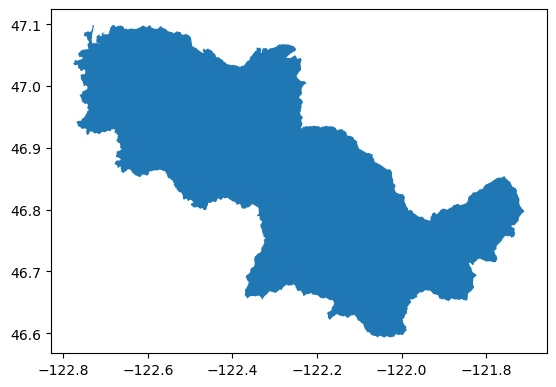

In [9]:
# Plot to see that it worked
nisqually_gdf.plot()

In [10]:
# Plot the results with web tile images
nisqually_gdf_plot = nisqually_gdf.hvplot(
    geo=True, tiles='EsriImagery',
    fill_color=None, line_color='white',
    title='Nisqually Watershed (HUC8)',
    frame_width=500,
    xlabel="Longitude",
    ylabel="Latitude")

# Display the plot with esri imagery
nisqually_gdf_plot

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]

### SRTM NASA DEM data downlaod (30-m resolution)


In [11]:
# Set up Earth Access
earthaccess.login()

In [12]:
# Search for SRTM data
datasets = earthaccess.search_datasets(keyword = "SRTM DEM")
for dataset in datasets:
    print(dataset['umm']['ShortName'], dataset['umm']['EntryTitle'])

ICRAF_AfSIS_AfrHySRTM Africa Soil Information Service (AfSIS): Hydrologically Corrected/Adjusted SRTM DEM (AfrHySRTM)
NASADEM_SHHP NASADEM SRTM-only Height and Height Precision Mosaic Global 1 arc second V001
NASADEM_SIM NASADEM SRTM Image Mosaic Global 1 arc second V001
NASADEM_SSP NASADEM SRTM Subswath Global 1 arc second V001
USGS_OFR_2004_1322 Digital Shaded-Relief Map of Venezuela
C_Pools_Fluxes_CONUS_1837 CMS: Terrestrial Carbon Stocks, Emissions, and Fluxes for Conterminous US, 2001-2016
GEDI02_B GEDI L2B Canopy Cover and Vertical Profile Metrics Data Global Footprint Level V002
SRTMGL1 NASA Shuttle Radar Topography Mission Global 1 arc second V003
NASADEM_HGT NASADEM Merged DEM Global 1 arc second V001
SRTMGL3 NASA Shuttle Radar Topography Mission Global 3 arc second V003
GEDI01_B GEDI L1B Geolocated Waveform Data Global Footprint Level V002
SRTMGL1N NASA Shuttle Radar Topography Mission Global 1 arc second number V003
NASADEM_NC NASADEM Merged DEM Global 1 arc second nc V001
S

In [13]:
# File pattern for data
nisqually_gdf_srtm_pattern = os.path.join(topography_dir, '*.hgt.zip')

# Study area for topo data
nisqually_gdf_elev_bounds = tuple(nisqually_gdf.total_bounds)

# Add buffer
buffer = 0.025
nisqually_xmin, nisqually_ymin, nisqually_xmax, nisqually_ymax = nisqually_gdf_elev_bounds
nisqually_elev_bounds_buffer = (nisqually_xmin - buffer,
                                 nisqually_ymin - buffer,
                                 nisqually_xmax + buffer,
                                 nisqually_ymax + buffer)

# Look at the results
srtm_files = glob(nisqually_gdf_srtm_pattern)

if not srtm_files:

    # Search for data
    nisqually_gdf_srtm_search = earthaccess.search_data(
        short_name = 'SRTMGL3',
        bounding_box = nisqually_elev_bounds_buffer
    )

    # Download data
    nisqually_gdf_srtm_results = earthaccess.download(
        nisqually_gdf_srtm_search,
        topography_dir
    )

# Add text if files already downloaded
else:
    print("SRTM files already downloaded")
    nisqually_gdf_srtm_results = srtm_files

SRTM files already downloaded


In [14]:
# Check it out
nisqually_gdf_srtm_results

['C:\\Users\\nymve\\Documents\\education\\earth-data-analytics\\spring-2026-data\\surface-runoff-susceptibility-model\\topography\\N46W122.SRTMGL3.hgt.zip',
 'C:\\Users\\nymve\\Documents\\education\\earth-data-analytics\\spring-2026-data\\surface-runoff-susceptibility-model\\topography\\N46W123.SRTMGL3.hgt.zip',
 'C:\\Users\\nymve\\Documents\\education\\earth-data-analytics\\spring-2026-data\\surface-runoff-susceptibility-model\\topography\\N47W122.SRTMGL3.hgt.zip',
 'C:\\Users\\nymve\\Documents\\education\\earth-data-analytics\\spring-2026-data\\surface-runoff-susceptibility-model\\topography\\N47W123.SRTMGL3.hgt.zip']

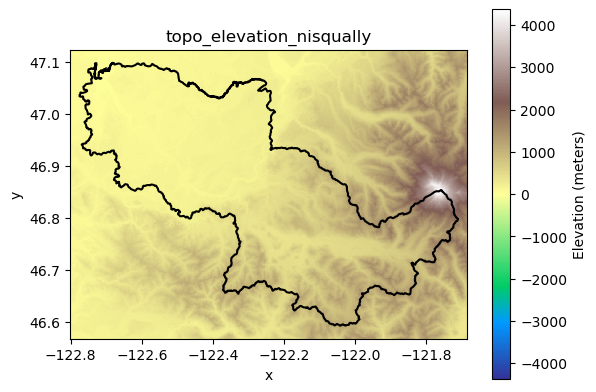

In [15]:
nisqually_gdf_srtm_da_list = []
for srtm_path in glob(nisqually_gdf_srtm_pattern):
    tile_da = rxr.open_rasterio(srtm_path, mask_and_scale = True).squeeze()
    srtm_cropped_da = tile_da.rio.clip_box(*nisqually_elev_bounds_buffer)
    nisqually_gdf_srtm_da_list.append(srtm_cropped_da)

# Merge 
nisqually_srtm_da = merge_arrays(nisqually_gdf_srtm_da_list)

nisqually_srtm_da.plot(cmap='terrain', cbar_kwargs={'label': 'Elevation (meters)'})

nisqually_gdf.boundary.plot(ax = plt.gca(), color='black')

# Add title
plt.title("topo_elevation_nisqually")

# Check it out
plt.show()

In [16]:
# Check the min and max values
print(nisqually_srtm_da.min().values)
print(nisqually_srtm_da.max().values)

-4.0
4371.0


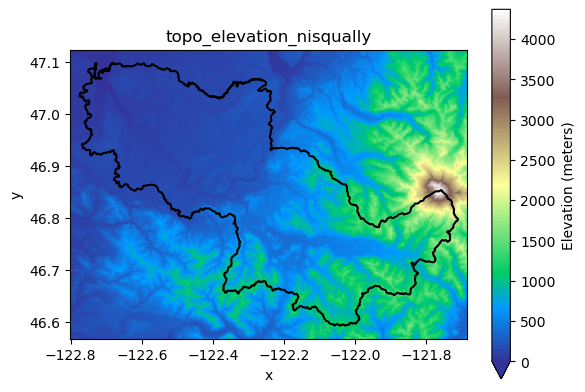

In [17]:
# Plot with limits for better visualization
nisqually_srtm_da.plot(
    cmap="terrain",
    vmin=0,
    vmax=float(nisqually_srtm_da.max()),
    cbar_kwargs={"label": "Elevation (meters)"}
)

# Add watershed boundary
nisqually_gdf.boundary.plot(ax=plt.gca(), color="black")
plt.title("topo_elevation_nisqually")
plt.show()

### NLCD Impervious Surface

In [18]:
# Path to zip file
zip_path = os.path.join(impervious_dir, "NLCD_84d4ec6e-782d-4ca1-985c-369c3d869faf.zip")

# Unzip to the same directory
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(impervious_dir)

# Check the extracted files
print("Unzipped successfully")

Unzipped successfully


In [19]:
# List the files in the impervious directory to see the extracted contents
for file in os.listdir(impervious_dir):
    print(file)

Annual_NLCD_FctImp_2024_CU_C1V1_84d4ec6e-782d-4ca1-985c-369c3d869faf.tiff
Annual_NLCD_FctImp_2024_CU_C1V1_84d4ec6e-782d-4ca1-985c-369c3d869faf.tiff.aux.xml
Annual_NLCD_FctImp_2024_CU_C1V1_84d4ec6e-782d-4ca1-985c-369c3d869faf.xml
extracted
NLCD Fractional Impervious Surface.gif
NLCD_84d4ec6e-782d-4ca1-985c-369c3d869faf.zip


In [20]:
# Find the tif
tif_files = [
    f for f in os.listdir(impervious_dir)
    if f.lower().endswith((".tif", ".tiff"))
]

# Check the tif files found
impervious_path = os.path.join(impervious_dir, tif_files[0])

# Open it
impervious_da = rxr.open_rasterio(impervious_path, masked=True).squeeze()

# Check the dataarray
print(impervious_da)

<xarray.DataArray (y: 5801, x: 7270)> Size: 169MB
[42173270 values with dtype=float32]
Coordinates:
  * y            (y) float64 46kB 3.01e+06 3.01e+06 ... 2.836e+06 2.836e+06
  * x            (x) float64 58kB -2.087e+06 -2.087e+06 ... -1.869e+06
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:             Area
    STATISTICS_MAXIMUM:        100
    STATISTICS_MEAN:           3.2224650619265
    STATISTICS_MINIMUM:        0
    STATISTICS_STDDEV:         12.153386299596
    STATISTICS_VALID_PERCENT:  63.85
    scale_factor:              1.0
    add_offset:                0.0


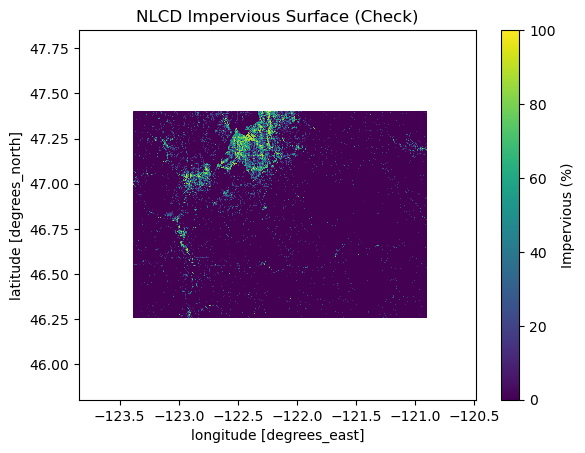

Min: 0.0
Max: 100.0


In [21]:
# Reproject to EPSG:4326 for plotting
impervious_plot = impervious_da.rio.reproject("EPSG:4326")

# Plot with limits for better visualization
impervious_plot.plot(
    cmap="viridis",
    cbar_kwargs={"label": "Impervious (%)"}
)

# Add title
plt.title("NLCD Impervious Surface (Check)")
plt.show()


# Check the min and max values
print("Min:", impervious_da.min().item())
print("Max:", impervious_da.max().item())

### MACA Climate Data

In [22]:
# Create function to convert longitude values
def convert_longitude(longitude):

    """
    Function to convert longitude

    Args:
    longitude:

    Returns:Function to convert longitude
    """
    
    return (longitude - 360) if longitude > 180 else longitude 

In [23]:
# Create directory for file
climate_pattern = os.path.join(climate_dir, '*.nc')
climate_pattern

'C:\\Users\\nymve\\Documents\\education\\earth-data-analytics\\spring-2026-data\\surface-runoff-susceptibility-model\\climate\\*.nc'

In [24]:
# Define some parameters
site_name = "Nisqually"
site_gdf = nisqually_gdf
date_range = "2041_2045"
model = "CCSM4"
rcp_value = "rcp45"
climate_var = "pr"

In [25]:
# Create a maca path
climate_path = os.path.join(
    climate_dir,
    f"maca_{model}_{site_name}_{date_range}_CONUS_daily.nc"
)

climate_full_tmp = os.path.join(
    climate_dir,
    f"maca_{model}_{date_range}_CONUS_FULL_tmp.nc"
)

In [26]:
# Construct the URL where the climate data lives
climate_url = (
    "http://thredds.northwestknowledge.net:8080/thredds/dodsC"
    "/MACAV2"
    f"/{model}"
    "/macav2metdata"
    f"_{climate_var}"
    f"_{model}_r6i1p1"
    f"_{rcp_value}"
    f"_{date_range}_CONUS"
    "_daily.nc"
)

In [27]:
# Check out the url
climate_url

'http://thredds.northwestknowledge.net:8080/thredds/dodsC/MACAV2/CCSM4/macav2metdata_pr_CCSM4_r6i1p1_rcp45_2041_2045_CONUS_daily.nc'

In [39]:
ds = xr.open_dataset(climate_url)
print(ds.data_vars)

Data variables:
    precipitation  (time, lat, lon) float32 6GB ...


In [40]:
climate_da = ds["pr"] if "pr" in ds.data_vars else ds["precipitation"]
print(climate_da)

<xarray.DataArray 'precipitation' (time: 1826, lat: 585, lon: 1386)> Size: 6GB
[1480539060 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 15kB 2041-01-01 2041-01-02 ... 2045-12-31
  * lat      (lat) float64 5kB 25.06 25.1 25.15 25.19 ... 49.27 49.31 49.35 49.4
  * lon      (lon) float64 11kB 235.2 235.3 235.3 235.4 ... 292.9 292.9 292.9
Attributes:
    long_name:      Precipitation
    units:          mm
    grid_mapping:   crs
    standard_name:  precipitation
    cell_methods:   time: sum(interval: 24 hours)
    comments:       Total daily precipitation at surface; includes both liqui...
    _ChunkSizes:    [162  51 123]


In [41]:
pt_raw = climate_da.sel(lat=46.85, lon=237.8, method="nearest")
print("Remote raw point min/max:", float(pt_raw.min()), float(pt_raw.max()))

Remote raw point min/max: 0.0 92.08182525634766


In [42]:
climate_da = climate_da.assign_coords(
    lon=(((climate_da.lon + 180) % 360) - 180).data
).sortby("lon")

In [43]:
pt_conv = climate_da.sel(lat=46.85, lon=-122.2, method="nearest")
print("Remote converted point min/max:", float(pt_conv.min()), float(pt_conv.max()))

Remote converted point min/max: 0.0 92.08182525634766


In [44]:
nisqually_4326 = nisqually_gdf.to_crs("EPSG:4326")
minx, miny, maxx, maxy = nisqually_4326.total_bounds
print(minx, miny, maxx, maxy)

-122.77620911906662 46.59305184666876 -121.71018763313434 47.09906060599487


In [45]:
climate_da_cropped = climate_da.sel(
    lon=slice(minx, maxx),
    lat=slice(miny, maxy)
)

In [46]:
pt_crop = climate_da_cropped.sel(lat=46.85, lon=-122.2, method="nearest")
print("Remote cropped point min/max:", float(pt_crop.min()), float(pt_crop.max()))

test_crop = climate_da_cropped.isel(time=0)
print("Remote cropped slice min/max:", float(test_crop.min()), float(test_crop.max()))
print(climate_da_cropped.shape)

Remote cropped point min/max: 0.0 92.08182525634766
Remote cropped slice min/max: 2.5459516048431396 17.12653923034668
(1826, 12, 26)


In [47]:
climate_da_cropped = climate_da_cropped.load()
print("Cropped subset loaded into memory")

Cropped subset loaded into memory


In [48]:
cropped_path = os.path.join(
    climate_dir,
    "maca_CCSM4_Nisqually_2041_2045_cropped.nc"
)

climate_da_cropped.to_netcdf(cropped_path)
print("Saved cropped file:", cropped_path)

Saved cropped file: C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\climate\maca_CCSM4_Nisqually_2041_2045_cropped.nc


In [49]:
ds_check = xr.open_dataset(cropped_path)
print(ds_check.data_vars)

check_da = ds_check["precipitation"] if "precipitation" in ds_check.data_vars else ds_check["pr"]

pt_check = check_da.sel(lat=46.85, lon=-122.2, method="nearest")
print("Local cropped point min/max:", float(pt_check.min()), float(pt_check.max()))

test_check = check_da.isel(time=0)
print("Local cropped slice min/max:", float(test_check.min()), float(test_check.max()))

Data variables:
    precipitation  (time, lat, lon) float32 2MB ...
Local cropped point min/max: 0.0 92.08182525634766
Local cropped slice min/max: 2.5459516048431396 17.12653923034668


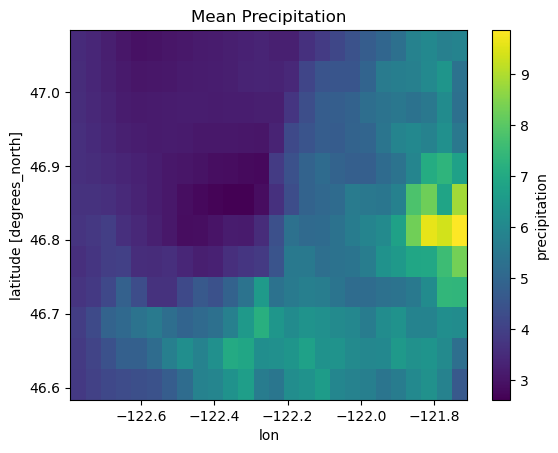

In [50]:
climate_mean = check_da.mean(dim="time")
climate_mean.plot()
plt.title("Mean Precipitation")
plt.show()

In [51]:
print(float(climate_mean.min()), float(climate_mean.max()))

2.611323833465576 9.863235473632812


In [52]:
climate_da_cropped.shape

(1826, 12, 26)

### NRCS Soil"????